<a href="https://colab.research.google.com/github/Sneha-code01/ML/blob/main/mi_12outlieremv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_28819/1326450082.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df)


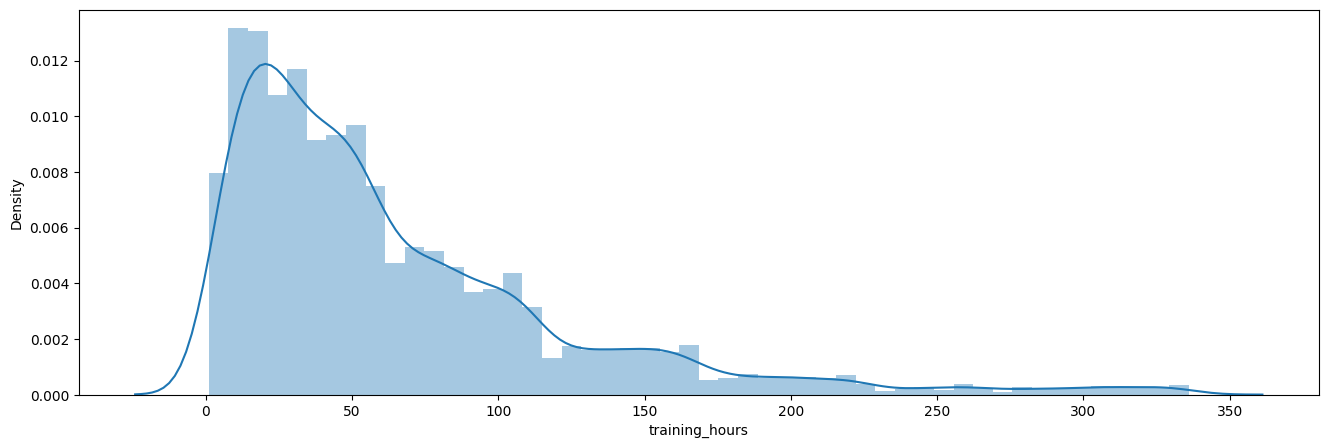

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/data_science_job.csv")['training_hours']
plt.figure(figsize=(16,5))
sns.distplot(df)
plt.show()

In [10]:
df.describe()

,training_hours
count,18392.000000
mean,65.185787
std,59.885626
min,1.000000
25%,23.000000
50%,47.000000
75%,88.000000
max,336.000000


<Axes: ylabel='training_hours'>

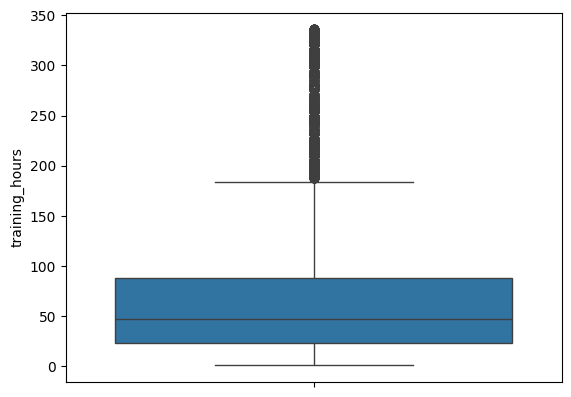

In [11]:
sns.boxplot(df)

In [12]:
iqr = 88 - 23
iqr

65

In [13]:
up_limit = 88 + 1.5*iqr
low_limit = 23 - 1.5*iqr

In [25]:
outlier = df[(df> up_limit)]
print(outlier)

69       228.0
89       332.0
110      210.0
119      260.0
133      290.0
         ...  
19082    266.0
19107    322.0
19117    214.0
19118    316.0
19145    190.0
Name: training_hours, Length: 936, dtype: float64


0         36.0
1         47.0
2         83.0
3         52.0
4          8.0
         ...  
19153     42.0
19154     52.0
19155     44.0
19156     97.0
19157    127.0
Name: training_hours, Length: 17456, dtype: float64


,training_hours
count,17456.000000
mean,55.408742
std,42.238236
min,1.000000
25%,22.000000
50%,45.000000
75%,80.000000
max,184.000000


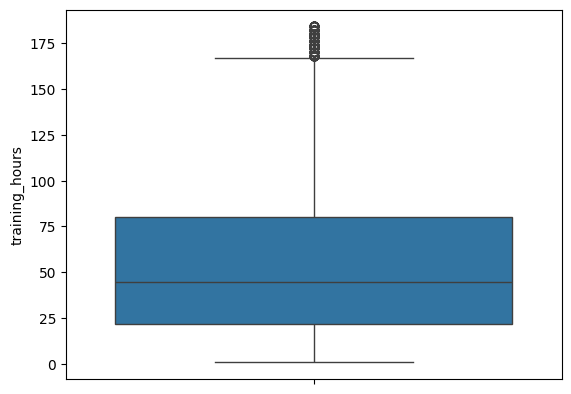

In [26]:
new_df = df[(df< up_limit)]
print(new_df)
sns.boxplot(new_df)
new_df.describe()

/tmp/ipykernel_28819/1624806939.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_dfcap)


<Axes: ylabel='Density'>

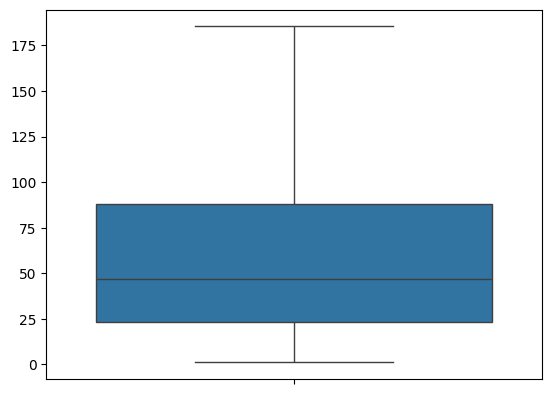

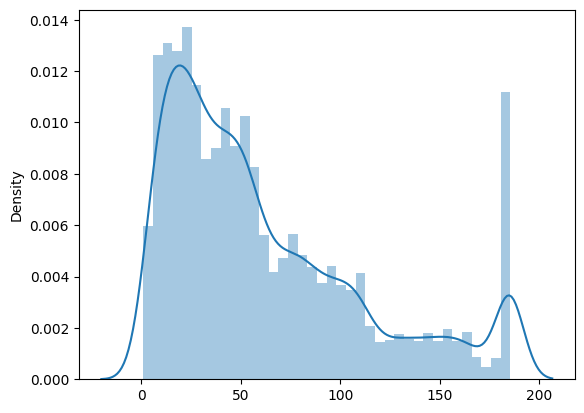

In [31]:
#capping
new_dfcap = df.copy()

new_dfcap = np.where(new_dfcap > up_limit, up_limit,
                     np.where(new_dfcap < low_limit, low_limit,
                              new_dfcap))
sns.boxplot(new_dfcap)
plt.figure()
sns.distplot(new_dfcap)